# Kernel-based Shrub-grass tansition model
This code is supplementary material for the article: "Phase transition in a dryland shrub–grass ecosystem: Emergence through local trade-offs"
> Code author: Jingyao Sun

Our study posits that the transition emerges bottom-up from intrinsic differences in resource-foraging strategies between shrubs and grasses. Conceptually, we treat plants as self-replicating resource-foraging units whose growth forms are collectively optimized for resource capture. Particularly in water-limited landscapes, individuals must extend root systems beyond their canopy extent, leading to spatial partitioning. Consequently, plant regeneration is governed by local interactions that are spatially structured by the existing vegetation pattern.

This kernel-based cellular automaton model assumes that each individual influences neighboring cells via an kernel combining local negative and positive effects. The summation of these kernels generates a continuous interaction field; within this field, each cell integrates the superimposed effects from all surrounding individuals. Plant dynamics depend on a cell's position within the interaction field: cells experiencing a strong net negative effect exhibit elevated mortality, whereas cells with a net positive effect permit colonization and expansion.

## Import libraries and define tools

In [1]:
import numpy as np
import pandas as pd
from scipy.signal import convolve2d, fftconvolve
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# kernel generation tool
def create_circle_matrix(R, kernel_size):
    """
    创建圆形矩阵核 | Create a circular matrix kernel
    
    Parameters:
    -----------
    R : float
        圆的半径 | Radius of the circle
    kernel_size : int
        核的大小（必须是奇数）| Kernel size (must be odd)
    
    Returns:
    --------
    matrix : numpy.ndarray
        二值圆形矩阵 | Binary circular matrix
    """
    if kernel_size % 2 == 0:
        raise ValueError("kernel_size must be an odd number")
    
    matrix = np.zeros((kernel_size, kernel_size), dtype=int)
    center_x, center_y = kernel_size // 2, kernel_size // 2
    
    for i in range(kernel_size):
        for j in range(kernel_size):
            distance = np.sqrt((i - center_x) ** 2 + (j - center_y) ** 2)
            if distance <= R:
                matrix[i, j] = 1
    
    return matrix

## Model initialization
We use different kernels to represent the trade-off between resource-foraging extensity and intensity in shrubs and grasses.
Resouce supply parameter (s) is the key.

s = 0.6 shrub win

s = 0.8 grass win

灌木核总和 | Shrub kernel sum: 7.843333333333334
灌木核唯一值 | Shrub kernel unique values: [-0.00337046  0.          0.00662954]
草地核总和 | Grass kernel sum: 4.95
草地核唯一值 | Grass kernel unique values: [0.         0.16241379 0.17241379]


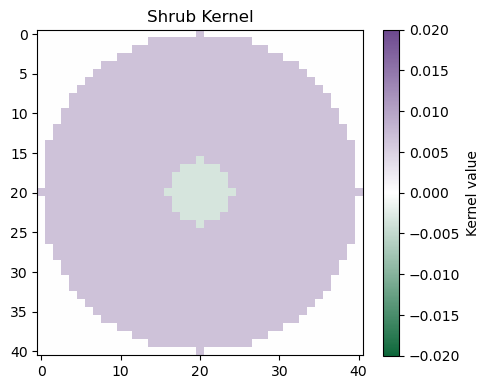

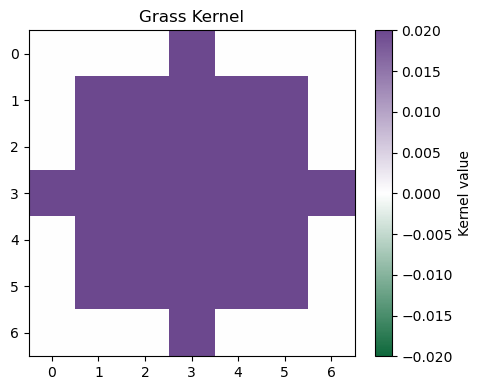

In [2]:
# 网格大小 | Grid size
n = 200

# 资源供给水平 | Resource supply level
# It is an important parameter. 
# s = 0.6 shrub win
# s = 0.8 grass win
s = 0.6

#--------------------------------------------------------------------#
# 定义灌木核 | Define Shrub Kernel

# 灌木的负效应和正效应半径 | Negative and positive effect radii for shrub
rn1 = 20  # 负效应半径 | Negative effect radius
rp1 = 4   # 正效应半径 | Positive effect radius

# 创建负效应核 | Create negative effect kernel
kn1 = create_circle_matrix(rn1, 2*rn1+1)
nn1 = np.count_nonzero(kn1)

# 创建正效应核 | Create positive effect kernel
kp1 = create_circle_matrix(rp1, 2*rn1+1)
np1 = np.count_nonzero(kp1)

# 资源消耗率 | Resource consumption rate for shrub
c1 = 5

# 计算灌木的综合核 | Calculate combined kernel for shrub
kn1 = kn1 * (c1/s) / nn1 - kp1 * 0.01

print(f"灌木核总和 | Shrub kernel sum: {np.sum(kn1)}")
print(f"灌木核唯一值 | Shrub kernel unique values: {np.unique(kn1)}")

#--------------------------------------------------------------------#
# 定义草地核 | Define Grass Kernel

# 草地的负效应和正效应半径 | Negative and positive effect radii for grass
rn2 = 3   # 负效应半径 | Negative effect radius
rp2 = 1   # 正效应半径 | Positive effect radius

# 创建负效应核 | Create negative effect kernel
kn2 = create_circle_matrix(rn2, 2*rn2+1)
nn2 = np.count_nonzero(kn2)

# 创建正效应核 | Create positive effect kernel
kp2 = create_circle_matrix(rp2, 2*rn2+1)
np2 = np.count_nonzero(kp2)

# 资源消耗率 | Resource consumption rate for grass
c2 = 3

# 计算草地的综合核 | Calculate combined kernel for grass
kn2 = kn2 * (c2/s) / nn2 - kp2 * 0.01

print(f"草地核总和 | Grass kernel sum: {np.sum(kn2)}")
print(f"草地核唯一值 | Grass kernel unique values: {np.unique(kn2)}")

#--------------------------------------------------------------------#
# 可视化核函数 | Visualize Kernels

# 创建自定义颜色映射 | Create custom colormap
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', ['#0E683B', 'white', '#6C488E'])
norm = plt.Normalize(vmin=-0.02, vmax=0.02)

# 可视化灌木核 | Visualize shrub kernel
plt.figure(figsize=(5, 4))
plt.imshow(kn1, cmap=cmap, norm=norm)
plt.colorbar(label='Kernel value')
plt.title('Shrub Kernel')
plt.tight_layout()
plt.show()

# 可视化草地核 | Visualize grass kernel
plt.figure(figsize=(5, 4))
plt.imshow(kn2, cmap=cmap, norm=norm)
plt.colorbar(label='Kernel value')
plt.title('Grass Kernel')
plt.tight_layout()
plt.show()

## Model simulation

In [3]:
# 初始密度 | Initial densities
p1 = 0.01  # 灌木初始密度 | Initial shrub density
p2 = 0.01  # 草地初始密度 | Initial grass density

# 创建初始分布矩阵 | Create initial distribution matrix
# 0: 空地 | Empty, 1: 灌木 | Shrub, 2: 草地 | Grass
matrix = np.random.choice([0, 1, 2], size=(n, n), p=[1-p1-p2, p1, p2])
matrix1 = matrix == 1  # 灌木分布 | Shrub distribution
matrix2 = matrix == 2  # 草地分布 | Grass distribution

# 记录密度变化 | Record density changes
density1 = []  # 灌木密度 | Shrub density
density2 = []  # 草地密度 | Grass density

#--------------------------------------------------------------------#
# 模型迭代 | Model Iteration

steps = 1000  # 迭代步数 | Number of steps

for i in range(steps):
    # 记录当前密度 | Record current densities
    density1.append(np.count_nonzero(matrix1) / n / n)
    density2.append(np.count_nonzero(matrix2) / n / n)
    
    # 扩散过程 | Dispersal process
    p1 = 0.5 * np.count_nonzero(matrix1) / n / n
    p2 = 0.5 * np.count_nonzero(matrix2) / n / n
    
    # 生成扩散矩阵（只在空地上）| Generate dispersal matrix (only on empty cells)
    matrix_dispersal = np.random.choice([0, 1, 2], size=(n, n), 
                                        p=[(1-p1-p2), p1, p2]) * (1-np.logical_or(matrix1, matrix2))
    matrix_dispersal1 = matrix_dispersal == 1
    matrix_dispersal2 = matrix_dispersal == 2
    
    # 合并现有植被和新扩散的植被 | Combine existing and newly dispersed vegetation
    matrix_arena1 = np.logical_or(matrix_dispersal1, matrix1)
    matrix_arena2 = np.logical_or(matrix_dispersal2, matrix2)
    
    # 扩展矩阵以进行卷积 | Pad matrices for convolution
    pad_width1 = ((kn1.shape[0] - 1) // 2, (kn1.shape[1] - 1) // 2)
    matrix_ext1 = np.pad(matrix_arena1, pad_width=pad_width1, mode='symmetric')
    netEffect1 = fftconvolve(matrix_ext1, kn1, mode='valid')
    
    pad_width2 = ((kn2.shape[0] - 1) // 2, (kn2.shape[1] - 1) // 2)
    matrix_ext2 = np.pad(matrix_arena2, pad_width=pad_width2, mode='symmetric')
    netEffect2 = fftconvolve(matrix_ext2, kn2, mode='valid')
    
    # 总影响场 | Total interaction field
    netEffect = netEffect1 + netEffect2
    
    # 植被动态（基于影响场）| Vegetation dynamics (based on interaction field)
    H1 = 1.0   # 灌木阈值 | Shrub threshold
    H2 = 1.1   # 草地阈值 | Grass threshold
    
    prob1 = matrix1 - (netEffect - H1) * 0.5
    prob2 = matrix2 - (netEffect - H2) * 0.5
    
    # 更新植被分布 | Update vegetation distribution
    matrix1 = (np.random.rand(n, n) < prob1) * matrix_arena1
    matrix2 = (np.random.rand(n, n) < prob2) * matrix_arena2
    
    #if i % 100 == 0:
    #    print(f"迭代步数 | Step: {i}")


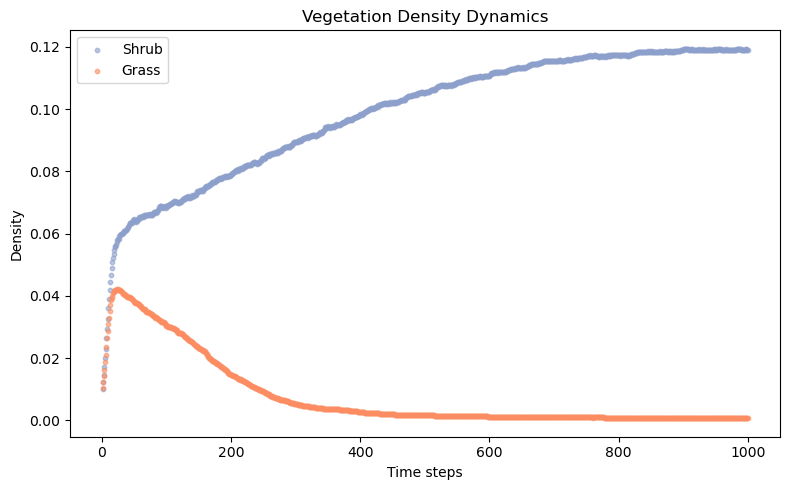

最终分布统计 | Final distribution statistics:
空地 | Empty (0): 35206
灌木 | Shrub (1): 4766
草地 | Grass (2): 28


In [4]:
# 密度变化图 | Density change plot
plt.figure(figsize=(8, 5))
plt.scatter(list(range(1, steps+1)), density1, c="#8DA0CB", label='Shrub', s=10, alpha=0.6)
plt.scatter(list(range(1, steps+1)), density2, c="#FC8D62", label='Grass', s=10, alpha=0.6)
plt.xlabel('Time steps')
plt.ylabel('Density')
plt.legend()
plt.title('Vegetation Density Dynamics')
plt.tight_layout()
plt.show()

# 最终分布统计 | Final distribution statistics
final_counts = pd.Series((matrix1 + 2*matrix2).flatten()).value_counts()
print("最终分布统计 | Final distribution statistics:")
print(f"空地 | Empty (0): {final_counts.get(0, 0)}")
print(f"灌木 | Shrub (1): {final_counts.get(1, 0)}")
print(f"草地 | Grass (2): {final_counts.get(2, 0)}")

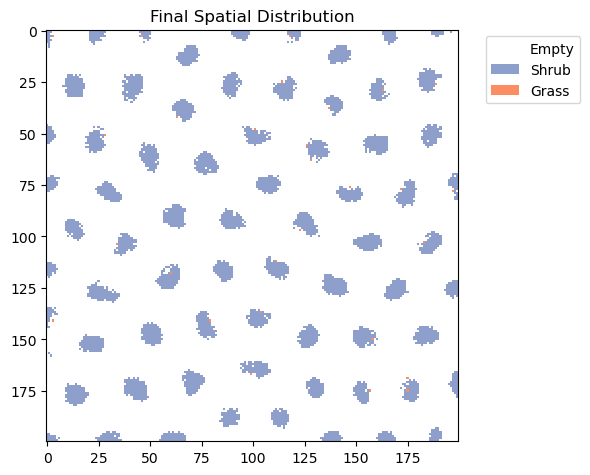

In [5]:
# 最终空间分布图 | Final spatial distribution plot
plt.figure(figsize=(6, 6))
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', ['white', '#8DA0CB', '#FC8D62'])
plt.imshow(matrix1 + 2*matrix2, cmap=cmap, interpolation='nearest')

# 创建自定义颜色条 | Create custom colorbar
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='white', label='Empty'),
    Patch(facecolor='#8DA0CB', label='Shrub'),
    Patch(facecolor='#FC8D62', label='Grass')
]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Final Spatial Distribution')
plt.tight_layout()
plt.show()

## Resource Suppliment-Level Sensitivity Analysis
We simulate the equilibrium densities and spatial patterns across a gradient of resource supplement (precipitation) levels. 
The results demonstrate that shrubs dominate under low-precipitation conditions, whereas grasses 
dominate under high-precipitation conditions. 
An intermediate bistable region emerges, where both 
species can potentially prevail, with the outcome determined by initial conditions.

In [70]:
final1 = []  # 最终灌木数量 | Final shrub count
final2 = []  # 最终草地数量 | Final grass count
sequence = np.arange(0.4, 1, 0.01)  # 资源水平序列 | Resource level sequence

# 对不同资源水平进行模拟 | Simulate for different resource levels

for j, s in enumerate(sequence):
    #print(f"处理资源水平 | Processing resource level: {s:.2f} ({j+1}/{len(sequence)})")
    
    # 重新计算核函数 | Recalculate kernels for current resource level
    # 灌木核 | Shrub kernel
    rn1, rp1, c1 = 20, 4, 5
    kn1 = create_circle_matrix(rn1, 2*rn1+1)
    nn1 = np.count_nonzero(kn1)
    kp1 = create_circle_matrix(rp1, 2*rn1+1)
    kn1 = kn1 * (c1/s) / nn1 - kp1 * 0.01
    
    # 草地核 | Grass kernel
    rn2, rp2, c2 = 3, 1, 3
    kn2 = create_circle_matrix(rn2, 2*rn2+1)
    nn2 = np.count_nonzero(kn2)
    kp2 = create_circle_matrix(rp2, 2*rn2+1)
    kn2 = kn2 * (c2/s) / nn2 - kp2 * 0.01
    
    # 初始化 | Initialize
    p1, p2 = 0.01, 0.01
    matrix = np.random.choice([0, 1, 2], size=(n, n), p=[1-p1-p2, p1, p2])
    matrix1 = matrix == 1
    matrix2 = matrix == 2
    
    # 运行模拟 | Run simulation
    steps = 2000
    for i in range(steps):
        # 扩散 | Dispersal
        p1 = 0.5 * np.count_nonzero(matrix1) / n / n
        p2 = 0.5 * np.count_nonzero(matrix2) / n / n
        matrix_dispersal = np.random.choice([0, 1, 2], size=(n, n), 
                                           p=[(1-p1-p2), p1, p2]) * (1-np.logical_or(matrix1, matrix2))
        matrix_dispersal1 = matrix_dispersal == 1
        matrix_dispersal2 = matrix_dispersal == 2
        matrix_arena1 = np.logical_or(matrix_dispersal1, matrix1)
        matrix_arena2 = np.logical_or(matrix_dispersal2, matrix2)
        
        # 卷积计算 | Convolution
        pad_width1 = ((kn1.shape[0] - 1) // 2, (kn1.shape[1] - 1) // 2)
        matrix_ext1 = np.pad(matrix_arena1, pad_width=pad_width1, mode='symmetric')
        netEffect1 = fftconvolve(matrix_ext1, kn1, mode='valid')
        
        pad_width2 = ((kn2.shape[0] - 1) // 2, (kn2.shape[1] - 1) // 2)
        matrix_ext2 = np.pad(matrix_arena2, pad_width=pad_width2, mode='symmetric')
        netEffect2 = fftconvolve(matrix_ext2, kn2, mode='valid')
        
        # 影响场和动态 | Influence field and dynamics
        netEffect = netEffect1 + netEffect2
        H1, H2 = 1.0, 1.1
        prob1 = matrix1 - (netEffect - H1) * 0.5
        prob2 = matrix2 - (netEffect - H2) * 0.5
        matrix1 = (np.random.rand(n, n) < prob1) * matrix_arena1
        matrix2 = (np.random.rand(n, n) < prob2) * matrix_arena2
    
    # 记录最终结果 | Record final results
    final1.append(np.sum(matrix1)/n/n)
    final2.append(np.sum(matrix2)/n/n)


## Visualization

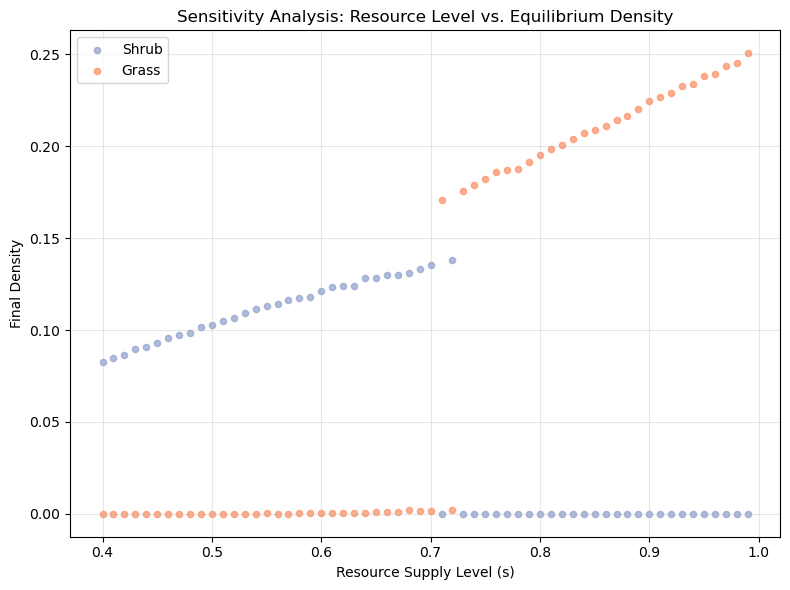

In [71]:
plt.figure(figsize=(8, 6))
plt.scatter(sequence, final1, c="#8DA0CB", label='Shrub', s=20, alpha=0.7)
plt.scatter(sequence, final2, c="#FC8D62", label='Grass', s=20, alpha=0.7)
plt.xlabel('Resource Supply Level (s)')
plt.ylabel('Final Density')
plt.title('Sensitivity Analysis: Resource Level vs. Equilibrium Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Resource_Sensitivity_Analysis.pdf", dpi=600, bbox_inches='tight')
plt.show()